<a href="https://colab.research.google.com/github/puneetbisarwal25/Deep-Learning-Basic/blob/main/gan_pytorch_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Importing Necessary Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Define Generator Function


In [2]:
class Generator(nn.Module):
    def __init__(self, noise_dim):
        super(Generator, self).__init__()
        self.noise_dim = noise_dim
        self.main = nn.Sequential(
            nn.Linear(noise_dim, 7 * 7 * 256),
            nn.ReLU(True),
            nn.Unflatten(1, (256, 7, 7)),
            nn.ConvTranspose2d(256, 128, 5, stride=1, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 5, stride=2,
                               padding=2, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 1, 5, stride=2,
                               padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.main(x)

## Step 3: Define Discriminator Function



In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
            nn.Flatten(),
            nn.Linear(7 * 7 * 128, 1)
        )

    def forward(self, x):
        return self.main(x)

## Step 4: Combining the Generator and Discriminator


In [6]:
NOISE_DIM = 100

generator = Generator(NOISE_DIM)
discriminator = Discriminator()

## Step 5: Device Configuration


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = generator.to(device)
discriminator = discriminator.to(device)

## Step 6: Set Loss Function, Optimizer and Hyperparameters


In [8]:
criterion = nn.BCEWithLogitsLoss()

generator_optimizer = optim.Adam(
    generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
discriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

NUM_EPOCHS = 5
BATCH_SIZE = 256

## Step 7: Prepare DataLoader


In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.64MB/s]


## Step 8: Training Process


In [10]:
for epoch in range(NUM_EPOCHS):
    for i, data in enumerate(train_loader):
        real_images, _ = data
        real_images = real_images.to(device)

        discriminator_optimizer.zero_grad()
        real_labels = torch.ones(real_images.size(0), 1, device=device)
        real_outputs = discriminator(real_images)
        real_loss = criterion(real_outputs, real_labels)
        real_loss.backward()

        noise = torch.randn(real_images.size(0), NOISE_DIM, device=device)
        fake_images = generator(noise)
        fake_labels = torch.zeros(real_images.size(0), 1, device=device)
        fake_outputs = discriminator(fake_images.detach())
        fake_loss = criterion(fake_outputs, fake_labels)
        fake_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()
        fake_labels = torch.ones(real_images.size(0), 1, device=device)
        fake_outputs = discriminator(fake_images)
        gen_loss = criterion(fake_outputs, fake_labels)
        gen_loss.backward()
        generator_optimizer.step()

        if i % 100 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{len(train_loader)}], '
                  f'Discriminator Loss: {real_loss.item() + fake_loss.item():.4f}, '
                  f'Generator Loss: {gen_loss.item():.4f}')

Epoch [1/5], Step [1/235], Discriminator Loss: 1.4723, Generator Loss: 1.0249
Epoch [1/5], Step [101/235], Discriminator Loss: 0.2091, Generator Loss: 4.7793
Epoch [1/5], Step [201/235], Discriminator Loss: 0.0635, Generator Loss: 4.4445
Epoch [2/5], Step [1/235], Discriminator Loss: 0.0455, Generator Loss: 4.7800
Epoch [2/5], Step [101/235], Discriminator Loss: 0.0807, Generator Loss: 5.1014
Epoch [2/5], Step [201/235], Discriminator Loss: 0.0326, Generator Loss: 5.0605
Epoch [3/5], Step [1/235], Discriminator Loss: 0.0274, Generator Loss: 5.1706
Epoch [3/5], Step [101/235], Discriminator Loss: 0.0317, Generator Loss: 5.9396
Epoch [3/5], Step [201/235], Discriminator Loss: 0.0408, Generator Loss: 5.9793
Epoch [4/5], Step [1/235], Discriminator Loss: 0.0262, Generator Loss: 5.8618
Epoch [4/5], Step [101/235], Discriminator Loss: 0.0171, Generator Loss: 5.7259
Epoch [4/5], Step [201/235], Discriminator Loss: 0.0041, Generator Loss: 6.4510
Epoch [5/5], Step [1/235], Discriminator Loss: 0

## Step 9: Visualization


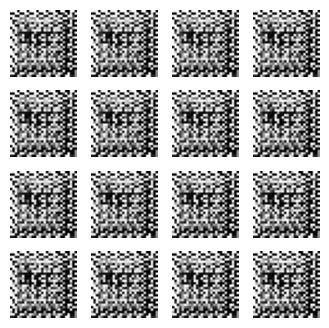

In [11]:
def generate_and_save_images(model, epoch, noise):
    model.eval()
    with torch.no_grad():
        fake_images = model(noise).cpu()
        fake_images = fake_images.view(fake_images.size(0), 28, 28)

        fig = plt.figure(figsize=(4, 4))
        for i in range(fake_images.size(0)):
            plt.subplot(4, 4, i + 1)
            plt.imshow(fake_images[i], cmap='gray')
            plt.axis('off')

        plt.savefig(f'image_at_epoch_{epoch+1:04d}.png')
        plt.show()


test_noise = torch.randn(16, NOISE_DIM, device=device)
generate_and_save_images(generator, NUM_EPOCHS, test_noise)